# 05 -- 转化漏斗分析

---

## 业务背景

用户从"打开网站"到"完成支付"，中间每多一步就流失一批人。漏斗分析的目标是**量化每一层流失的经济损失，并找到最值得优化的环节**。

我们的漏斗层级（基于 sessions 表）：
```
全部会话 (Sessions)
  → 非跳出会话 (Engaged)
    → 有加购行为的会话 (Cart Added)
      → 产生交易的会话 (Converted)
        → 实际完成支付 (Completed)
```

每一步的转化率 × 流失价值，决定了优化优先级。

## 1. 环境与数据

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.express as px
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11
plt.rcParams["font.sans-serif"] = ["SimHei", "Microsoft YaHei", "WenQuanYi Micro Hei", "sans-serif"]
plt.rcParams["axes.unicode_minus"] = False

sessions = pd.read_parquet('../output/sessions_clean.parquet')
txn_wide = pd.read_parquet('../output/transactions_wide.parquet')
customers = pd.read_parquet('../output/customers_clean.parquet')

completed_txn = txn_wide[txn_wide['status'] == 'completed']
print(f"Sessions: {len(sessions):,}")
print(f"Transactions (completed): {len(completed_txn):,}")

C:\Users\Acer\AppData\Roaming\Python\Python313\site-packages\pandas\core\computation\expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


Sessions: 80,000
Transactions (completed): 68,700


## 2. 整体转化漏斗

In [2]:
# 计算各漏斗层级
total_sessions = len(sessions)
engaged = sessions[sessions['bounced'] == 0]  # 非跳出 = 看了 2 页以上
total_engaged = len(engaged)
cart_sessions = sessions[sessions['cart_additions'] > 0]
total_cart = len(cart_sessions)
converted_sessions = sessions[sessions['converted'] == 1]
total_converted = len(converted_sessions)

# 已支付订单（合并 sessions 和 transactions 的逻辑）
# converted=1 的 session 中，实际在 transactions 中完成的
converted_customers = converted_sessions['customer_id'].unique()
conv_txn = completed_txn[completed_txn['customer_id'].isin(converted_customers)]
total_completed = conv_txn['transaction_id'].nunique()

funnel = pd.DataFrame({
    '阶段': ['全部会话', '有效浏览\n(未跳出)', '加购行为', '产生交易', '完成支付'],
    '数量': [total_sessions, total_engaged, total_cart, total_converted, total_completed]
})
funnel['整体转化率'] = (funnel['数量'] / total_sessions * 100).round(2)
funnel['逐层转化率'] = [100.0] + [
    funnel['数量'].iloc[i] / funnel['数量'].iloc[i-1] * 100
    for i in range(1, len(funnel))
]
funnel['逐层转化率'] = funnel['逐层转化率'].round(2)

# Plotly 漏斗图
fig = go.Figure()
fig.add_trace(go.Funnel(
    y=funnel['阶段'],
    x=funnel['数量'],
    textposition='inside',
    texttemplate='%{value:,.0f}<br>整体: %{customdata:.1f}%<br>逐层: %{hovertext}%',
    customdata=funnel['整体转化率'],
    hovertext=funnel['逐层转化率'],
    marker=dict(
        color=['#3498db', '#2ecc71', '#f39c12', '#e74c3c', '#9b59b6'],
        line=dict(width=0)
    )
))
fig.update_layout(
    title=dict(text='整体转化漏斗', font=dict(size=18)),
    height=500
)
fig.show()

print("=== 漏斗数据 ===")
print(funnel.to_string(index=False))

# 最大流失环节
drops = [funnel['数量'].iloc[i-1] - funnel['数量'].iloc[i] for i in range(1, len(funnel))]
drop_stages = [f"{funnel['阶段'].iloc[i-1].replace(chr(10),' ')} → {funnel['阶段'].iloc[i].replace(chr(10),' ')}"
               for i in range(1, len(funnel))]
max_drop_idx = drops.index(max(drops))
print(f"\n最大流失环节: {drop_stages[max_drop_idx]} (流失 {drops[max_drop_idx]:,})")

=== 漏斗数据 ===
         阶段    数量  整体转化率  逐层转化率
       全部会话 80000 100.00 100.00
有效浏览\n(未跳出) 72746  90.93  90.93
       加购行为 37229  46.54  51.18
       产生交易  8648  10.81  23.23
       完成支付 41314  51.64 477.73

最大流失环节: 有效浏览 (未跳出) → 加购行为 (流失 35,517)


**业务解读：**
- 漏斗最宽的地方到最窄的地方，就是转化效率的天花板
- **最大流失环节**是第一优先级优化点——流失人数最多，哪怕提升 1% 也能带来可观的 GMV 增长
- 注意：不同环节的优化成本和难度不同。比如"加购到支付"可能通过简化支付流程提升，但"浏览到加购"需要商品力和内容力


## 3. 各环节流失的经济价值

只看人数还不够，我们要量化每个流失环节的**潜在经济损失**。

平均客单价: 79.23


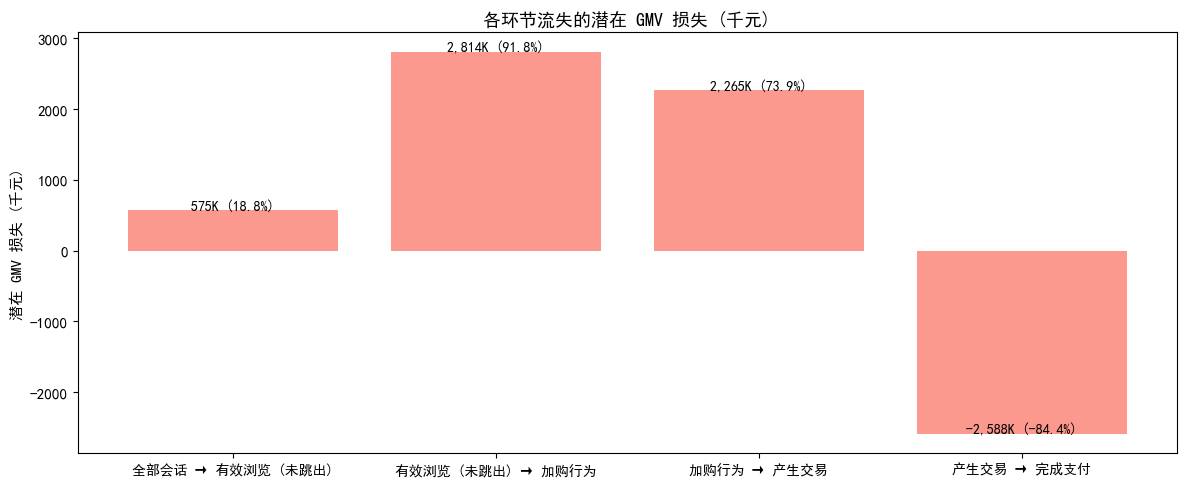

=== 经济损失评估 ===
             流失环节   流失人数    假设客单价       潜在GMV损失  损失占比
全部会话 → 有效浏览 (未跳出)   7254 79.23214  5.747499e+05  18.8
有效浏览 (未跳出) → 加购行为  35517 79.23214  2.814088e+06  91.8
      加购行为 → 产生交易  28581 79.23214  2.264534e+06  73.9
      产生交易 → 完成支付 -32666 79.23214 -2.588197e+06 -84.4


In [3]:
# 计算每个环节的潜在 GMV 损失
avg_order_value = completed_txn['total_amount'].mean()
print(f"平均客单价: {avg_order_value:.2f}")

economic_loss = []
for i in range(1, len(funnel)):
    lost_users = funnel['数量'].iloc[i-1] - funnel['数量'].iloc[i]
    # 假设这些流失用户如果转化，会贡献平均客单价
    potential_loss = lost_users * avg_order_value
    economic_loss.append({
        '流失环节': drop_stages[i-1],
        '流失人数': lost_users,
        '假设客单价': avg_order_value,
        '潜在GMV损失': potential_loss
    })

loss_df = pd.DataFrame(economic_loss)
loss_df['损失占比'] = (loss_df['潜在GMV损失'] / loss_df['潜在GMV损失'].sum() * 100).round(1)

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(range(len(loss_df)), loss_df['潜在GMV损失']/1000, color='salmon', alpha=0.8)
ax.set_xticks(range(len(loss_df)))
ax.set_xticklabels(loss_df['流失环节'], fontsize=10)
ax.set_title('各环节流失的潜在 GMV 损失 (千元)', fontsize=13, fontweight='bold')
ax.set_ylabel('潜在 GMV 损失 (千元)')

for i, (val, pct) in enumerate(zip(loss_df['潜在GMV损失'], loss_df['损失占比'])):
    ax.text(i, val/1000 + 2, f'{val/1000:,.0f}K ({pct}%)', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

print("=== 经济损失评估 ===")
print(loss_df.to_string(index=False))

**业务解读：**
- 这个分析把"流失"从抽象数字变成了具体的**钱**
- 最大的经济损失环节，就是 CTO/产品经理最该优先解决的
- 注意这里的客单价假设是均值，实际情况中不同环节的流失用户可能有不同的预期价值（比如加购用户可能买的是高价商品）


## 4. 漏斗 × 设备维度：哪个设备转化最差？

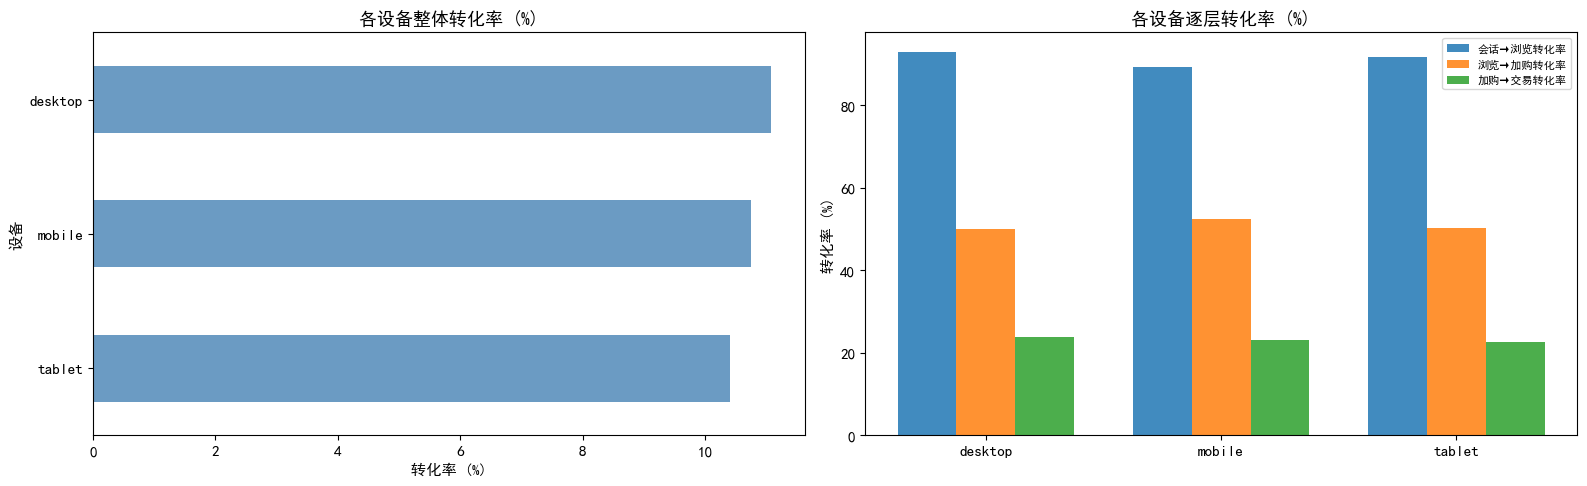

=== 设备漏斗明细 ===
          全部会话   有效浏览   加购行为  产生交易  会话→浏览转化率  浏览→加购转化率  加购→交易转化率  整体转化率
设备                                                                     
desktop  28053  26080  13038  3106      93.0      50.0      23.8   11.1
mobile   40010  35737  18704  4300      89.3      52.3      23.0   10.7
tablet   11937  10929   5487  1242      91.6      50.2      22.6   10.4


In [4]:
# 按设备拆解漏斗
device_funnel = []
for device in sessions['device'].unique():
    sub = sessions[sessions['device'] == device]
    total = len(sub)
    engaged_d = len(sub[sub['bounced'] == 0])
    cart_d = len(sub[sub['cart_additions'] > 0])
    conv_d = len(sub[sub['converted'] == 1])

    device_funnel.append({
        '设备': device,
        '全部会话': total,
        '有效浏览': engaged_d,
        '加购行为': cart_d,
        '产生交易': conv_d,
        '会话→浏览转化率': engaged_d/total*100,
        '浏览→加购转化率': cart_d/engaged_d*100 if engaged_d > 0 else 0,
        '加购→交易转化率': conv_d/cart_d*100 if cart_d > 0 else 0,
        '整体转化率': conv_d/total*100
    })

device_df = pd.DataFrame(device_funnel).set_index('设备')

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 整体转化率对比
device_df['整体转化率'].sort_values().plot.barh(ax=axes[0], color='steelblue', alpha=0.8)
axes[0].set_title('各设备整体转化率 (%)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('转化率 (%)')

# 逐层转化率对比
stages = ['会话→浏览转化率', '浏览→加购转化率', '加购→交易转化率']
x_pos = np.arange(len(device_df))
width = 0.25
for i, stage in enumerate(stages):
    axes[1].bar(x_pos + i*width, device_df[stage], width, alpha=0.85, label=stage)
axes[1].set_xticks(x_pos + width)
axes[1].set_xticklabels(device_df.index)
axes[1].set_title('各设备逐层转化率 (%)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('转化率 (%)')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

print("=== 设备漏斗明细 ===")
print(device_df.round(1).to_string())

**业务解读：**
- 移动端转化率通常低于桌面端，但如果差距过大（> 50%），说明移动端体验有严重问题（页面加载慢、支付流程复杂等）
- 如果 Tablet 转化率高但流量少 → 可能是"沙发购物"场景，可以定向投放
- 优化优先级 = 流量大 × 转化率低的设备


## 5. 漏斗 × 渠道维度：哪个渠道来的用户最值钱？

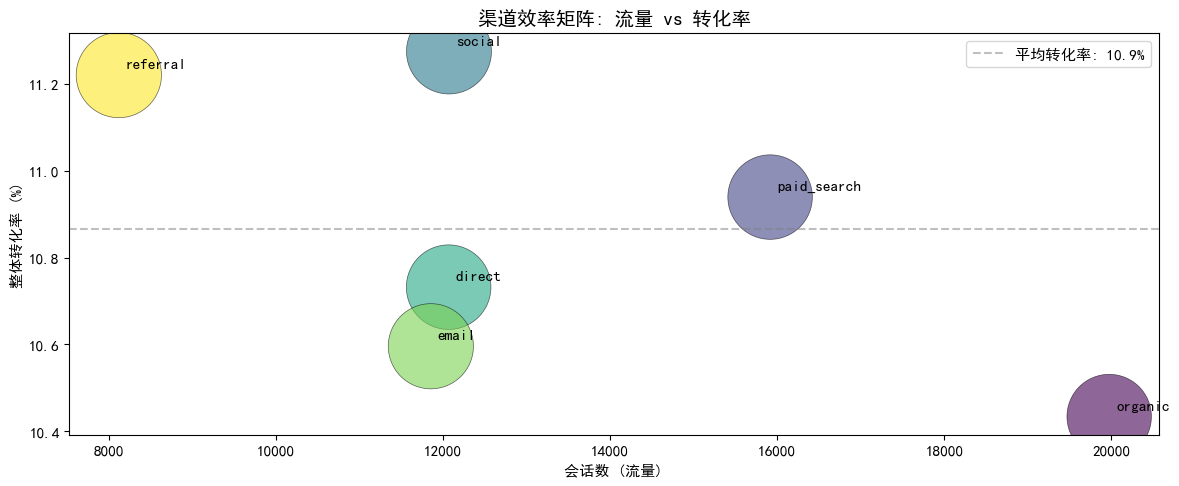

=== 渠道漏斗明细 ===
               会话数   会话占比  整体转化率    加购率
渠道                                     
organic      19974  24.97  10.43  46.21
paid_search  15915  19.89  10.94  46.28
social       12071  15.09  11.27  46.76
direct       12067  15.08  10.73  46.37
email        11854  14.82  10.60  47.01
referral      8119  10.15  11.22  47.09


In [5]:
# 按渠道拆解
channel_funnel = []
for channel in sessions['channel'].unique():
    sub = sessions[sessions['channel'] == channel]
    total = len(sub)
    engaged_c = len(sub[sub['bounced'] == 0])
    cart_c = len(sub[sub['cart_additions'] > 0])
    conv_c = len(sub[sub['converted'] == 1])

    channel_funnel.append({
        '渠道': channel,
        '会话数': total,
        '会话占比': total/len(sessions)*100,
        '整体转化率': conv_c/total*100,
        '加购率': cart_c/total*100
    })

channel_df = pd.DataFrame(channel_funnel).set_index('渠道').sort_values('会话数', ascending=False)

fig, ax = plt.subplots(figsize=(12, 5))

# 气泡图：渠道流量 vs 转化率，气泡大小 = 加购率
scatter = ax.scatter(
    channel_df['会话数'], channel_df['整体转化率'],
    s=channel_df['加购率'] * 80, alpha=0.6,
    c=range(len(channel_df)), cmap='viridis',
    edgecolors='black', linewidth=0.5
)

for name, row in channel_df.iterrows():
    ax.annotate(name, (row['会话数'], row['整体转化率']),
                textcoords="offset points", xytext=(5, 5), fontsize=11, fontweight='bold')

ax.set_xlabel('会话数 (流量)')
ax.set_ylabel('整体转化率 (%)')
ax.set_title('渠道效率矩阵: 流量 vs 转化率', fontsize=14, fontweight='bold')
ax.axhline(y=channel_df['整体转化率'].mean(), color='gray', linestyle='--', alpha=0.5,
           label=f'平均转化率: {channel_df["整体转化率"].mean():.1f}%')
ax.legend()

plt.tight_layout()
plt.show()

print("=== 渠道漏斗明细 ===")
print(channel_df.round(2).to_string())

**业务解读——渠道四象限：**
- **高流量+高转化**（右上）：黄金渠道，加大投放预算
- **高流量+低转化**（右下）：流量质量差或落地页不匹配，优化承接体验
- **低流量+高转化**（左上）：精准渠道，适合高客单价商品推广
- **低流量+低转化**（左下）：评估是否值得继续投入


## 6. 漏斗的时间趋势：转化率在改善还是恶化？

逐月看转化率变化，判断产品和运营的优化是否有效。

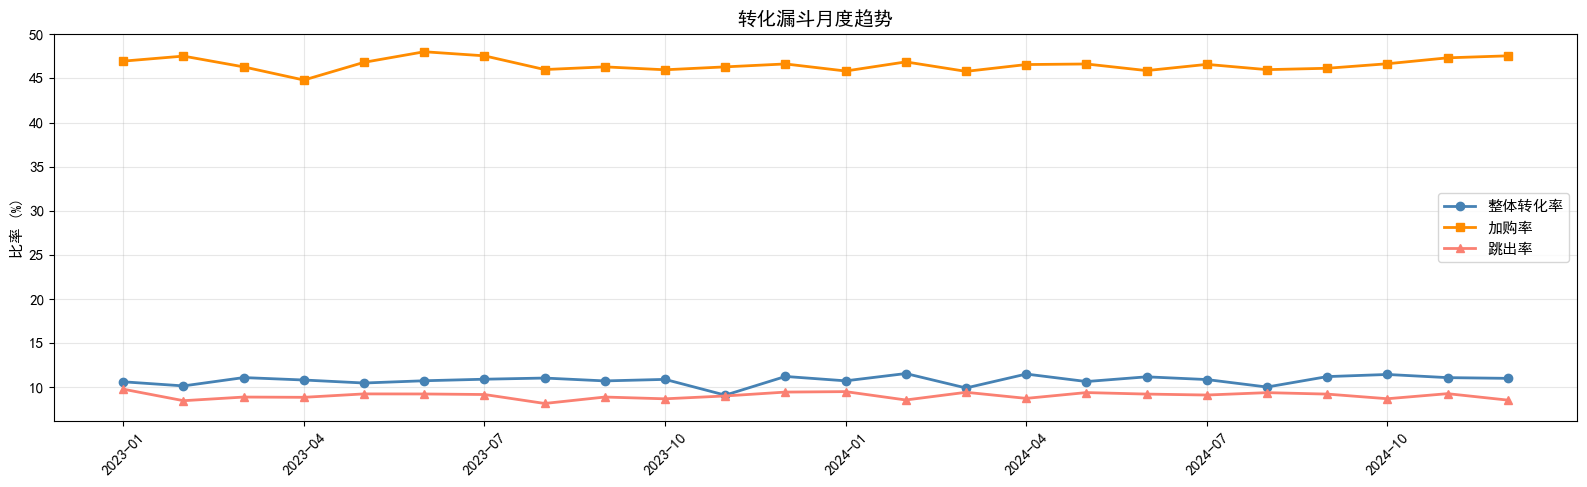

前半段平均转化率: 10.67%
后半段平均转化率: 10.95%
转化率趋势: 上升 (变化 0.28 个百分点)


In [6]:
# 月度转化漏斗
monthly_funnel = []
for ym in sorted(sessions['year_month'].unique()):
    sub = sessions[sessions['year_month'] == ym]
    total = len(sub)
    engaged_m = len(sub[sub['bounced'] == 0])
    cart_m = len(sub[sub['cart_additions'] > 0])
    conv_m = len(sub[sub['converted'] == 1])

    monthly_funnel.append({
        'year_month': str(ym),
        'sessions': total,
        'overall_cvr': conv_m/total*100,
        'cart_rate': cart_m/total*100,
        'bounce_rate': (1 - engaged_m/total)*100
    })

mfd = pd.DataFrame(monthly_funnel)

fig, ax = plt.subplots(figsize=(16, 5))

ax.plot(range(len(mfd)), mfd['overall_cvr'], marker='o', linewidth=2, color='steelblue', label='整体转化率')
ax.plot(range(len(mfd)), mfd['cart_rate'], marker='s', linewidth=2, color='darkorange', label='加购率')
ax.plot(range(len(mfd)), mfd['bounce_rate'], marker='^', linewidth=2, color='salmon', label='跳出率')

ax.set_xticks(range(0, len(mfd), 3))
ax.set_xticklabels(mfd['year_month'].iloc[::3], rotation=45)
ax.set_title('转化漏斗月度趋势', fontsize=14, fontweight='bold')
ax.set_ylabel('比率 (%)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 趋势判断
first_half_cvr = mfd['overall_cvr'].iloc[:len(mfd)//2].mean()
second_half_cvr = mfd['overall_cvr'].iloc[len(mfd)//2:].mean()
trend = "上升" if second_half_cvr > first_half_cvr else "下降"
print(f"前半段平均转化率: {first_half_cvr:.2f}%")
print(f"后半段平均转化率: {second_half_cvr:.2f}%")
print(f"转化率趋势: {trend} (变化 {abs(second_half_cvr - first_half_cvr):.2f} 个百分点)")

**业务解读：**
- 转化率总体趋势向上 → 产品和运营优化在起作用
- 转化率持平或下降 → 流量结构可能在变化（更多低质量流量），或者竞品在抢用户
- 跳出率上升通常和两个因素有关：流量质量下降，或页面加载速度变慢


---

## 7.小结

| 分析维度 | 关键发现 | 优化建议 |
|----------|---------|---------|
| 整体漏斗 | 最大流失在 X → Y 环节 | 这是 P0 优化项，优先级最高 |
| 经济损失 | 每环节的 GMV 损失量化 | 用"潜在损失"说服决策者分配资源 |
| 设备差异 | XX 设备转化率最低 | 针对性优化该设备的体验 |
| 渠道效率 | XX 渠道高流量低转化 | 优化落地页 or 调整投放策略 |
| 时间趋势 | 转化率呈上升/下降趋势 | 验证过往优化策略是否有效 |

**核心结论：** 优化漏斗不是"每层都提 1%"，而是**找到流失最大的那一个环节，集中资源打透**。这个分析就是帮你找到该打哪里。
